In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [3]:
df = pd.read_csv("../data/raw/loan_data.csv")

In [4]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [5]:
X["loan_to_income"] = (
    X["loan_amnt"] / X["person_income"]
)

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [9]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [11]:
logistic_model = LogisticRegression(
    max_iter=1000
)

In [12]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

In [30]:
logistic_pipeline.fit(
    X_train,
    y_train
)

import joblib

joblib.dump(
    logistic_pipeline,
    "../models/logistic_regression_pipeline.joblib"
)

['../models/logistic_regression_pipeline.joblib']

In [14]:
y_pred = logistic_pipeline.predict(X_test)

In [15]:
y_pred[:20]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

In [16]:
y_probability = logistic_pipeline.predict_proba(X_test)

In [18]:
y_probability[:5]

array([[9.73747529e-01, 2.62524715e-02],
       [9.99968171e-01, 3.18288674e-05],
       [9.99998360e-01, 1.63953073e-06],
       [9.99977116e-01, 2.28843054e-05],
       [5.44895357e-01, 4.55104643e-01]])

In [21]:
y_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [23]:
print("Model: Logistic Regression")
print("-" * 35)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model: Logistic Regression
-----------------------------------
Accuracy : 0.8992
Precision: 0.7875
Recall   : 0.7485
F1 Score : 0.7675
ROC-AUC  : 0.9562


In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[6596  404]
 [ 503 1497]]


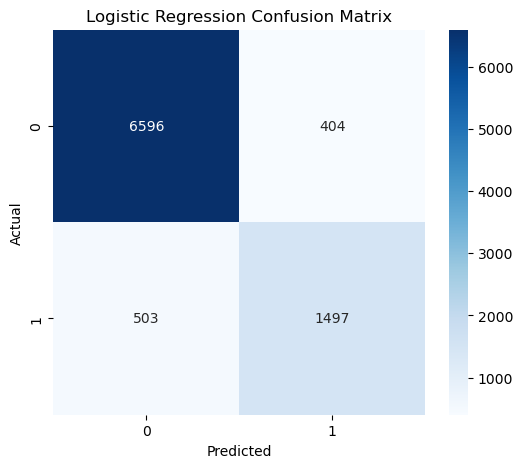

In [26]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

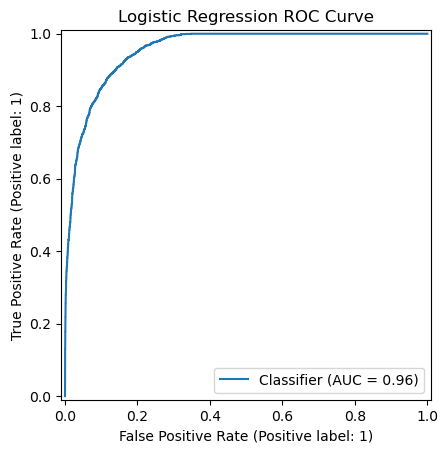

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [28]:
thresholds = np.arange(
    0.1,
    1.0,
    0.1
)

results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            predictions
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.1,0.540067,0.9705,0.693958
1,0.2,0.613983,0.9265,0.738541
2,0.3,0.675883,0.8800,0.764553
3,0.4,0.734648,0.8195,0.774758
4,0.5,0.787480,0.7485,0.767496
5,0.6,0.844002,0.6790,0.752563
6,0.7,0.885805,0.5585,0.685066
7,0.8,0.931492,0.4215,0.580379
8,0.9,0.981557,0.2395,0.385048


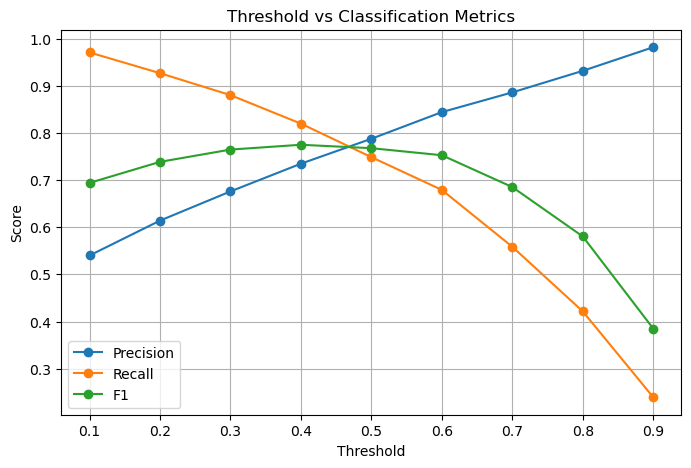

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1"

)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.legend()
plt.grid()

plt.show()